In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import precision_recall_curve, roc_curve, auc

from qpitome_qrc.data.loaders import load_market_stress_data
from qpitome_qrc.data.sequences import make_rolling_sequences, chronological_split
from qpitome_qrc.baselines.esn import (
    DEFAULT_FEATURES,
    TARGET,
    ESNConfig,
    grid_configs,
    run_esn_grid_search,
    fit_single_esn,
    prediction_frame,
)


In [2]:
from pathlib import Path
import os

# run this once near top of notebook
if Path.cwd().name == "notebooks":
    os.chdir("..")

print(Path.cwd())

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility


In [4]:
df = load_market_stress_data()

X, y, dates = make_rolling_sequences(
    df=df,
    features=DEFAULT_FEATURES,
    target=TARGET,
    seq_len=20,
)

splits = chronological_split(X, y, dates)

for name, (_, yy, dd) in splits.items():
    print(name, yy.shape, dd.min(), dd.max(), dict(zip(*np.unique(yy, return_counts=True))))

train (5692,) 1993-05-24T00:00:00.000000 2015-12-31T00:00:00.000000 {np.int64(0): np.int64(4497), np.int64(1): np.int64(1195)}
val (1006,) 2016-01-04T00:00:00.000000 2019-12-31T00:00:00.000000 {np.int64(0): np.int64(898), np.int64(1): np.int64(108)}
test (1073,) 2020-01-02T00:00:00.000000 2024-04-08T00:00:00.000000 {np.int64(0): np.int64(806), np.int64(1): np.int64(267)}


In [5]:
from qpitome_qrc.baselines.esn import (
    DEFAULT_FEATURES,
    TARGET,
    grid_configs,
    run_esn_grid_search,
)

configs = grid_configs(
    units=(300, 600),
    spectral_radius=(0.7, 0.9),
    leak_rate=(0.2, 0.5),
    reservoir_connectivity=(0.05, 0.1),
    readout_C=(0.1, 1.0),
    seeds=(1, 2),
)

summary, best = run_esn_grid_search(
    splits=splits,
    configs=configs,
    selection_metric="val_pr_auc",
)

summary.head(10)

[1/64] ESNConfig(units=300, spectral_radius=0.7, leak_rate=0.2, input_scaling=0.5, input_connectivity=0.5, reservoir_connectivity=0.05, readout_C=0.1, seed=1)
[2/64] ESNConfig(units=300, spectral_radius=0.7, leak_rate=0.2, input_scaling=0.5, input_connectivity=0.5, reservoir_connectivity=0.05, readout_C=0.1, seed=2)
[3/64] ESNConfig(units=300, spectral_radius=0.7, leak_rate=0.2, input_scaling=0.5, input_connectivity=0.5, reservoir_connectivity=0.05, readout_C=1.0, seed=1)
[4/64] ESNConfig(units=300, spectral_radius=0.7, leak_rate=0.2, input_scaling=0.5, input_connectivity=0.5, reservoir_connectivity=0.05, readout_C=1.0, seed=2)
[5/64] ESNConfig(units=300, spectral_radius=0.7, leak_rate=0.2, input_scaling=0.5, input_connectivity=0.5, reservoir_connectivity=0.1, readout_C=0.1, seed=1)
[6/64] ESNConfig(units=300, spectral_radius=0.7, leak_rate=0.2, input_scaling=0.5, input_connectivity=0.5, reservoir_connectivity=0.1, readout_C=0.1, seed=2)
[7/64] ESNConfig(units=300, spectral_radius=0.7,

,units,spectral_radius,leak_rate,input_scaling,input_connectivity,reservoir_connectivity,readout_C,seed,threshold,val_balanced_accuracy,...,val_pr_auc,val_precision_class_1,val_recall_class_1,val_f1_class_1,test_balanced_accuracy,test_roc_auc,test_pr_auc,test_precision_class_1,test_recall_class_1,test_f1_class_1
0,300,0.7,0.2,0.5,0.5,0.05,0.1,1,0.50,0.754568,...,0.553876,0.549550,0.564815,0.557078,0.699931,0.813083,0.669169,0.382943,0.857678,0.529480
1,300,0.9,0.2,0.5,0.5,0.05,0.1,1,0.50,0.754011,...,0.552807,0.544643,0.564815,0.554545,0.668902,0.804811,0.664992,0.354037,0.853933,0.500549
2,600,0.7,0.2,0.5,0.5,0.05,0.1,1,0.56,0.745690,...,0.547981,0.585859,0.537037,0.560386,0.730878,0.826456,0.701478,0.425573,0.835206,0.563843
3,600,0.9,0.2,0.5,0.5,0.05,0.1,1,0.55,0.745690,...,0.547313,0.585859,0.537037,0.560386,0.720930,0.825945,0.705021,0.415414,0.827715,0.553191
4,300,0.7,0.2,0.5,0.5,0.10,0.1,1,0.52,0.757352,...,0.541767,0.575472,0.564815,0.570093,0.733313,0.812739,0.659956,0.434524,0.820225,0.568093
5,600,0.7,0.2,0.5,0.5,0.05,0.1,2,0.54,0.744020,...,0.539098,0.568627,0.537037,0.552381,0.748144,0.826526,0.656752,0.465217,0.801498,0.588721
6,300,0.7,0.5,0.5,0.5,0.05,0.1,1,0.56,0.729399,...,0.538588,0.593407,0.500000,0.542714,0.748225,0.815215,0.652714,0.452869,0.827715,0.585430
7,300,0.9,0.2,0.5,0.5,0.10,0.1,1,0.51,0.762538,...,0.537500,0.584906,0.574074,0.579439,0.724008,0.810810,0.650181,0.421965,0.820225,0.557252
8,300,0.9,0.5,0.5,0.5,0.05,0.1,1,0.50,0.736606,...,0.533684,0.537736,0.527778,0.532710,0.702377,0.808361,0.652304,0.388316,0.846442,0.532391
9,300,0.7,0.2,0.5,0.5,0.10,0.1,2,0.39,0.799163,...,0.532774,0.486842,0.685185,0.569231,0.722953,0.833673,0.688500,0.401709,0.880150,0.551643


In [7]:
from qpitome_qrc.baselines.esn import prediction_frame

_, y_val, dates_val = splits["val"]
_, y_test, dates_test = splits["test"]

pred_val = prediction_frame(
    dates=dates_val,
    y_true=y_val,
    y_score=best.val_scores,
    threshold=best.threshold,
)

pred_test = prediction_frame(
    dates=dates_test,
    y_true=y_test,
    y_score=best.test_scores,
    threshold=best.threshold,
)

pred_test.head()

,date,y_true,y_score,y_pred
0,2020-01-02,0,0.027985,0
1,2020-01-03,0,0.067506,0
2,2020-01-06,0,0.092110,0
3,2020-01-07,0,0.096189,0
4,2020-01-08,0,0.089138,0


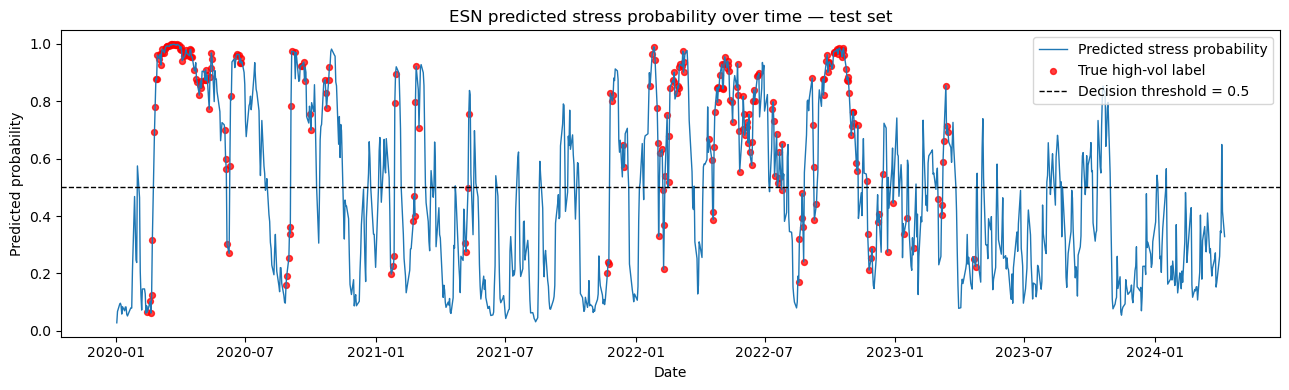

In [8]:
plt.figure(figsize=(13, 4))
plt.plot(pred_test["date"], pred_test["y_score"], label="Predicted stress probability", linewidth=1)
plt.scatter(
    pred_test.loc[pred_test["y_true"] == 1, "date"],
    pred_test.loc[pred_test["y_true"] == 1, "y_score"],
    s=18,
    color="red",
    alpha=0.75,
    label="True high-vol label",
)
plt.axhline(0.5, linestyle="--", color="black", linewidth=1, label="Decision threshold = 0.5")
plt.title("ESN predicted stress probability over time — test set")
plt.xlabel("Date")
plt.ylabel("Predicted probability")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
pred_test["error_type"] = "correct"
pred_test.loc[(pred_test["y_true"] == 0) & (pred_test["y_pred"] == 1), "error_type"] = "false_positive"
pred_test.loc[(pred_test["y_true"] == 1) & (pred_test["y_pred"] == 0), "error_type"] = "false_negative"

pred_test["error_type"].value_counts()

error_type
correct           664
false_positive    364
false_negative     45
Name: count, dtype: int64

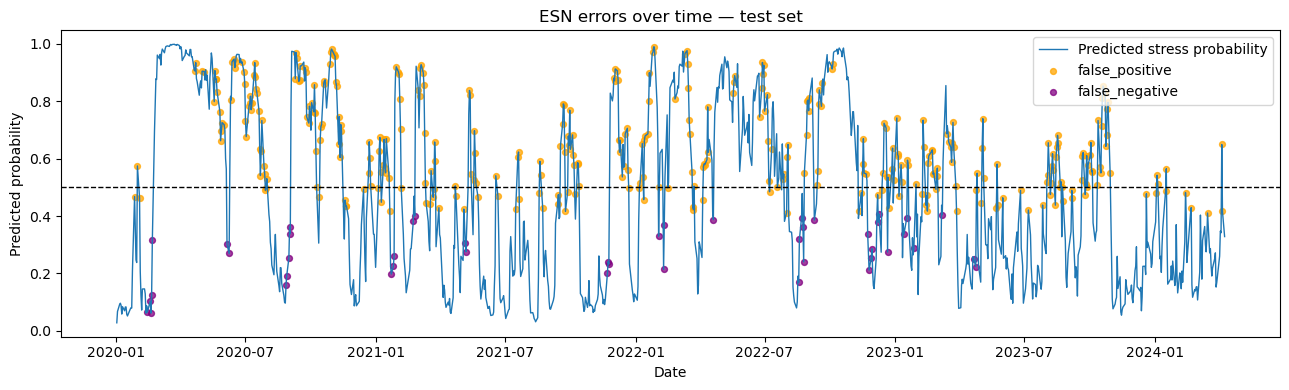

In [10]:
plt.figure(figsize=(13, 4))
plt.plot(pred_test["date"], pred_test["y_score"], linewidth=1, label="Predicted stress probability")

for label, color in [
    ("false_positive", "orange"),
    ("false_negative", "purple"),
]:
    sub = pred_test[pred_test["error_type"] == label]
    plt.scatter(sub["date"], sub["y_score"], s=18, alpha=0.75, label=label, color=color)

plt.axhline(0.5, linestyle="--", color="black", linewidth=1)
plt.title("ESN errors over time — test set")
plt.xlabel("Date")
plt.ylabel("Predicted probability")
plt.legend()
plt.tight_layout()
plt.show()

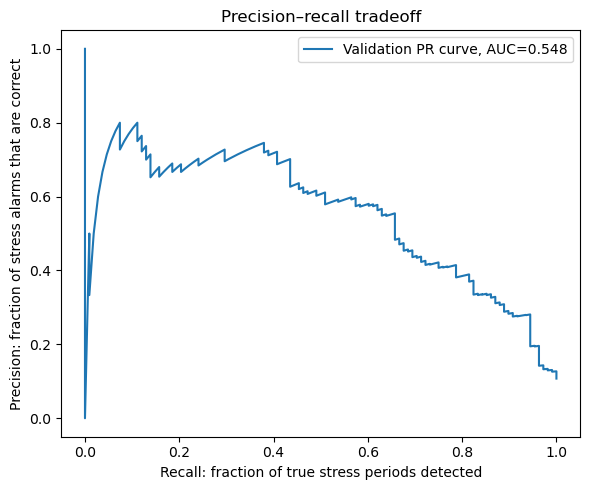

In [11]:
precision, recall, thresholds = precision_recall_curve(pred_val["y_true"], pred_val["y_score"])
pr_auc_val = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"Validation PR curve, AUC={pr_auc_val:.3f}")
plt.xlabel("Recall: fraction of true stress periods detected")
plt.ylabel("Precision: fraction of stress alarms that are correct")
plt.title("Precision–recall tradeoff")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
rows = []

for thr in np.linspace(0.1, 0.9, 17):
    y_pred = (pred_val["y_score"] >= thr).astype(int)
    tp = ((pred_val["y_true"] == 1) & (y_pred == 1)).sum()
    fp = ((pred_val["y_true"] == 0) & (y_pred == 1)).sum()
    fn = ((pred_val["y_true"] == 1) & (y_pred == 0)).sum()
    tn = ((pred_val["y_true"] == 0) & (y_pred == 0)).sum()

    precision_thr = tp / (tp + fp) if (tp + fp) else 0
    recall_thr = tp / (tp + fn) if (tp + fn) else 0
    f1_thr = 2 * precision_thr * recall_thr / (precision_thr + recall_thr) if (precision_thr + recall_thr) else 0

    rows.append({
        "threshold": thr,
        "precision": precision_thr,
        "recall": recall_thr,
        "f1": f1_thr,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,precision,recall,f1,tp,fp,fn,tn
0,0.10,0.217021,0.944444,0.352941,102,368,6,530
1,0.15,0.282421,0.907407,0.430769,98,249,10,649
2,0.20,0.327526,0.870370,0.475949,94,193,14,705
3,0.25,0.372385,0.824074,0.512968,89,150,19,748
4,0.30,0.410891,0.768519,0.535484,83,119,25,779
5,0.35,0.451220,0.685185,0.544118,74,90,34,808
6,0.40,0.537879,0.657407,0.591667,71,61,37,837
7,0.45,0.572650,0.620370,0.595556,67,50,41,848
8,0.50,0.585859,0.537037,0.560386,58,41,50,857
9,0.55,0.609195,0.490741,0.543590,53,34,55,864


In [13]:
best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
best_threshold = best_row["threshold"]

print("Best validation threshold by F1:", best_threshold)
best_row

Best validation threshold by F1: 0.45000000000000007


threshold      0.450000
precision      0.572650
recall         0.620370
f1             0.595556
tp            67.000000
fp            50.000000
fn            41.000000
tn           848.000000
Name: 7, dtype: float64

In [14]:
for split_name, pred in [("validation", pred_val), ("test", pred_test)]:
    y_pred = (pred["y_score"] >= best_threshold).astype(int)

    tp = ((pred["y_true"] == 1) & (y_pred == 1)).sum()
    fp = ((pred["y_true"] == 0) & (y_pred == 1)).sum()
    fn = ((pred["y_true"] == 1) & (y_pred == 0)).sum()
    tn = ((pred["y_true"] == 0) & (y_pred == 0)).sum()

    precision_thr = tp / (tp + fp) if (tp + fp) else 0
    recall_thr = tp / (tp + fn) if (tp + fn) else 0
    f1_thr = 2 * precision_thr * recall_thr / (precision_thr + recall_thr) if (precision_thr + recall_thr) else 0

    print(split_name)
    print("threshold:", best_threshold)
    print("precision:", precision_thr)
    print("recall:", recall_thr)
    print("f1:", f1_thr)
    print("confusion matrix [[tn, fp], [fn, tp]]:")
    print([[tn, fp], [fn, tp]])
    print()

validation
threshold: 0.45000000000000007
precision: 0.5726495726495726
recall: 0.6203703703703703
f1: 0.5955555555555555
confusion matrix [[tn, fp], [fn, tp]]:
[[np.int64(848), np.int64(50)], [np.int64(41), np.int64(67)]]

test
threshold: 0.45000000000000007
precision: 0.39421338155515373
recall: 0.8164794007490637
f1: 0.5317073170731708
confusion matrix [[tn, fp], [fn, tp]]:
[[np.int64(471), np.int64(335)], [np.int64(49), np.int64(218)]]



In [5]:
from qpitome_qrc.baselines.esn import ESNConfig, fit_single_esn

config = ESNConfig(
    units=600,
    spectral_radius=0.7,
    leak_rate=0.5,
    input_scaling=0.5,
    input_connectivity=0.5,
    reservoir_connectivity=0.1,
    readout_C=0.1,
    seed=1,
    washout=0,
    pooling="final",
    scale_states=False,
)

best = fit_single_esn(
    splits=splits,
    config=config,
    tune_threshold=True,
)

print("threshold:", best.threshold)
print("val:", best.val_metrics)
print("test:", best.test_metrics)

threshold: 0.4099999999999999
val: ClassificationMetrics(balanced_accuracy=0.7969665099397839, roc_auc=0.8974985564629216, pr_auc=0.5547340194630631, precision_class_1=0.5546875, recall_class_1=0.6574074074074074, f1_class_1=0.6016949152542372, confusion_matrix=array([[841,  57],
       [ 37,  71]]))
test: ClassificationMetrics(balanced_accuracy=0.6899238854657485, roc_auc=0.8128084311484094, pr_auc=0.636956993873568, precision_class_1=0.378839590443686, recall_class_1=0.8314606741573034, f1_class_1=0.5205158264947245, confusion_matrix=array([[442, 364],
       [ 45, 222]]))
